# Обучение AutoGluon Quantile Regression

В данном ноутбуке выполняется обучение моделей квантильной регрессии для прогнозирования
биологических характеристик химических соединений — активности (`pIC50`), цитотоксичности
(`pCC50`) и индекса селективности (`log10_SI`). Каждый таргет обучается отдельно.

## Архитектура модели

Для моделирования использовалась библиотека **AutoGluon** (`TabularPredictor`) с типом задачи
`problem_type='quantile'`. Модель предсказывает не точечное значение таргета, а сразу четыре
квантиля: `q10`, `q50`, `q90` и `q95`. Это позволяет оценивать не только центральный прогноз,
но и неопределённость предсказания — нижний и верхний сценарии для каждого соединения.

## Ключевые параметры обучения

| Параметр              | Значение          | Смысл                                              |
|-----------------------|-------------------|----------------------------------------------------|
| `presets`             | `best_quality`    | Максимальное качество моделей, долгое обучение     |
| `time_limit`          | 1800 сек (30 мин) | Ограничение времени на обучение                    |
| `num_bag_folds`       | 5                 | 5-кратный кросс-валидационный бэггинг              |
| `num_stack_levels`    | 1                 | Один уровень стэкинга ансамблей                    |
| `calibrate`           | `True`            | Калибровка предсказанных квантилей                 |
| `feature_prune_kwargs`| `force_prune=True`| Принудительный pruning слабых признаков            |
| `keep_only_best`      | `True`            | Сохраняется только лучшая модель для экономии места|

## Обоснование выбора квантильной регрессии

Целевые переменные `pIC50`, `pCC50` и `log10_SI` имеют несимметричные распределения с тяжёлыми
хвостами. Квантильная регрессия не требует предположения о нормальности ошибок и устойчива к
выбросам, что делает её предпочтительным выбором по сравнению со стандартной регрессией среднего.
Прогноз сразу нескольких квантилей также позволяет формировать интервальные оценки для итоговых
предсказаний.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:

from autogluon.tabular import TabularPredictor
import os

/opt/miniconda3/envs/ag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка исходных данных (с новыми признаками)

In [3]:
train = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/train_selected.csv')
train.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed,pIC50,pCC50,log10_SI
0,2.471240,-2.203512,2.178787,0.155539,32.166506,10.291948,2.063714,0.241070,2.590056,2.162989,...,0,0,0,1,0,0,0.681165,0.989639,1.018827,-0.029188
1,2.314947,-2.449813,2.456783,-0.003171,35.495692,9.631497,2.157249,0.155411,3.202665,5.979250,...,0,0,0,0,0,0,0.769122,4.353274,2.075665,2.277609
2,2.579710,-2.562182,2.584438,-0.007335,16.507764,9.486685,1.480238,0.332383,3.271705,3.649563,...,0,0,0,0,0,0,0.612606,2.352816,1.300287,1.052529
3,3.101827,-2.040425,2.409619,-0.384432,32.227747,10.102030,2.026965,0.162038,4.970214,5.111900,...,0,0,0,0,0,0,0.345823,2.165714,0.165714,2.000000
4,1.787472,-2.547053,2.539193,0.000365,14.788664,9.531931,1.940004,0.308846,3.002350,1.657054,...,0,0,0,0,0,0,0.562066,2.698264,1.154893,1.543371


In [4]:
test = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/test_selected.csv')
test.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_ketone_Topliss,fr_methoxy,fr_nitro,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed
0,3.494848,-2.425359,2.544663,-0.147725,32.166547,9.704289,1.531269,0.173188,3.264259,3.565174,...,0,0,0,0,0,0,1,0,0,0.770057
1,2.752143,-2.390353,2.369524,-0.277225,16.707906,9.991346,1.885708,0.269334,4.373269,2.230052,...,0,0,0,3,0,0,0,0,0,0.278628
2,2.001545,-2.580818,2.603245,-0.063729,14.717158,9.477838,1.911265,0.320711,3.081114,2.190560,...,0,0,0,0,0,0,0,0,0,0.657472
3,3.093791,-2.378300,2.497185,-0.343838,19.431747,9.748466,2.061305,0.161809,4.035225,4.196103,...,1,0,0,0,0,0,0,0,0,0.564307
4,2.896060,-2.201773,2.471778,-0.097822,16.731298,9.952325,1.940561,0.093867,3.310435,2.390479,...,1,0,0,0,0,0,0,0,0,0.696213


In [5]:
print(train.shape)
print(test.shape)

(751, 113)
(250, 110)


In [6]:
# ==========================================
# 1. НАСТРОЙКИ ДЛЯ ОДНОГО ТАРГЕТА
# ==========================================
target = 'pIC50'
other_targets = ['pCC50', 'log10_SI']

save_path = '/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/log_models_pIC50'
quantile_levels = [0.1, 0.5, 0.9, 0.95]

print(f"\n{'='*50}")
print(f"Обучение AutoGluon для таргета: {target}")
print(f"{'='*50}")

# 1) Удаляем другие таргеты
train_data_target = train.drop(columns=other_targets, errors='ignore').copy()

print("train_data_target shape:", train_data_target.shape)
print("Количество признаков:", train_data_target.shape[1] - 1)
print("Quantile levels:", quantile_levels)

# ==========================================
# 2. СОЗДАЕМ ПРЕДИКТОР ДЛЯ QUANTILE REGRESSION
# ==========================================
predictor = TabularPredictor(
    label=target,
    path=os.path.join(save_path, f"model_{target}_quantile"),
    problem_type='quantile',
    quantile_levels=quantile_levels
)

# ==========================================
# 3. ЗАПУСКАЕМ ОБУЧЕНИЕ
# ==========================================
predictor.fit(
    train_data=train_data_target,
    presets='best_quality',
    time_limit=1800,
    calibrate=True,
    feature_prune_kwargs={'force_prune': True},
    num_bag_folds=5,
    num_bag_sets=1,
    num_stack_levels=1,
    keep_only_best=True
)

print(f"Обучение quantile-модели для таргета {target} завершено.")

Verbosity: 2 (Standard Logging)



Обучение AutoGluon для таргета: pIC50
train_data_target shape: (751, 111)
Количество признаков: 110
Quantile levels: [0.1, 0.5, 0.9, 0.95]


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:34 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T8103
CPU Count:          8
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.64 GB / 8.00 GB (33.0%)
Disk Space Avail:   32.06 GB / 228.27 GB (14.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stac

Обучение quantile-модели для таргета pIC50 завершено.


In [7]:
#  Оценка качества на кросс-валидации (OOF)
print(f"\n--- Результаты кросс-валидации для {target} ---")
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard[['model', 'score_val', 'fit_time']])

print(f"\n Лучшая модель: {predictor.model_best}")


--- Результаты кросс-валидации для pIC50 ---
                         model  score_val   fit_time
0          WeightedEnsemble_L3  -0.141988  67.219388
1    NeuralNetTorch_r22_BAG_L1  -0.145660   5.950575
2            LightGBMXT_BAG_L2  -0.146234  41.454227
3              CatBoost_BAG_L2  -0.146611  59.745450
4          LightGBM_r94_BAG_L1  -0.148869   7.990236
5       ExtraTrees_r172_BAG_L1  -0.149193   2.055210
6     RandomForest_r127_BAG_L1  -0.149430   4.078714
7          CatBoost_r50_BAG_L1  -0.152179   9.399148
8  NeuralNetFastAI_r111_BAG_L1  -0.154311   4.525393

 Лучшая модель: WeightedEnsemble_L3


Computing feature importance via permutation shuffling for 110 features using 500 rows with 3 shuffle sets...


	986.49s	= Expected runtime (328.83s per shuffle set)
	1008.95s	= Actual runtime (Completed 3 of 3 shuffle sets)



Топ-20 важных признаков:
                          importance    stddev   p_value  n  p99_high   p99_low
fr_bicyclic                 0.003232  0.001525  0.033415  3  0.011970 -0.005505
Chi_Complexity              0.003170  0.000926  0.013644  3  0.008477 -0.002136
NumSaturatedHeterocycles    0.003145  0.000862  0.012071  3  0.008084 -0.001795
Chi_to_RingCount            0.002735  0.000555  0.006732  3  0.005917 -0.000447
EState_VSA8                 0.002619  0.000510  0.006202  3  0.005540 -0.000303
Ring_to_Atom                0.001981  0.000112  0.000535  3  0.002625  0.001337
NumAliphaticCarbocycles     0.001922  0.000982  0.038548  3  0.007548 -0.003705
VSA_EState8                 0.001906  0.000248  0.002794  3  0.003325  0.000486
Lipinski_Violations         0.001885  0.000155  0.001129  3  0.002776  0.000995
BCUT2D_MRLOW                0.001724  0.000139  0.001074  3  0.002518  0.000930
EState_VSA3                 0.001714  0.000232  0.003032  3  0.003044  0.000383
fr_NH2        

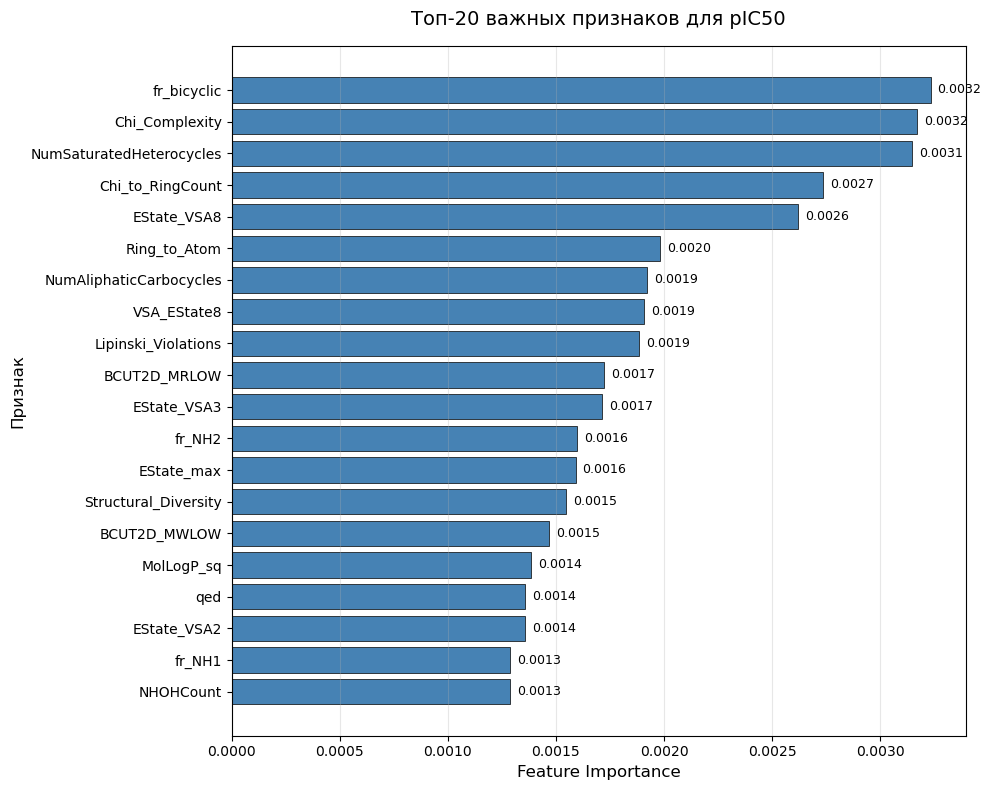

График сохранён: /Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/log_models_pIC50/feature_importance_pIC50_top20.png


In [17]:
# ==========================================
# 4. ВАЖНОСТЬ ПРИЗНАКОВ
# ==========================================
feature_importance = predictor.feature_importance(
    train_data_target,
    num_shuffle_sets=3,    
    subsample_size=500
)    

print("\nТоп-20 важных признаков:")
print(feature_importance.head(20).to_string())

# Сохраняем таблицу
feature_importance.to_csv(
    os.path.join(save_path, f"feature_importance_{target}.csv")
)

# ==========================================
# 5. ГРАФИК ТОП-20 ПРИЗНАКОВ
# ==========================================
import matplotlib.pyplot as plt

top20 = feature_importance.head(20).copy()

# feature_importance возвращает индекс = название признака, колонка = importance
top20 = top20.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top20.index,
    top20["importance"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

# Подписи значений на барах
for bar, val in zip(bars, top20["importance"]):
    ax.text(
        val + top20["importance"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9
    )

ax.set_title(f"Топ-20 важных признаков для {target}", fontsize=14, pad=15)
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_ylabel("Признак", fontsize=12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(save_path, f"feature_importance_{target}_top20.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"График сохранён: {plot_path}")

In [8]:
# Предсказание pIC50 на тесте
print("\nГенерация предсказаний pIC50 для тестового набора...")
pred_test_quantiles_pIC50 = predictor.predict(test) 
print(pred_test_quantiles_pIC50.head())
print(pred_test_quantiles_pIC50.columns)


Генерация предсказаний pIC50 для тестового набора...
       0.10      0.50      0.90      0.95
0  0.555310  1.305022  2.084160  2.303208
1  0.062913  0.920809  1.575621  1.884531
2  0.872099  1.423765  2.338210  2.581494
3  0.253669  0.973273  1.833837  2.069687
4  0.136852  0.835693  1.636613  1.933307
Index([0.1, 0.5, 0.9, 0.95], dtype='float64')


In [9]:
# 1. Узнаем точное имя лучшей модели
best_model_name = predictor.model_best
print(f" Лучшая модель: {best_model_name}\n")

# 2. Достаем всё досье на эту модель
model_details = predictor.model_info(best_model_name)

# 3. Смотрим, какие базовые модели в нее вошли (и с какими весами)
print(" Веса базовых моделей в ансамбле:")
# Если это ансамбль, у него есть ключ 'children_info' или 'stacker_info'
if 'children_info' in model_details:
    # Выводим веса (какая модель внесла наибольший вклад)
    weights = model_details['children_info']['S1F1']['model_weights']
    for model, weight in weights.items():
        if weight > 0: # Показываем только те, что реально используются
            print(f"  - {model}: {weight:.4f}")

# 4. Выводим гиперпараметры самого ансамбля
print("\n Гиперпараметры лучшей модели:")
print(model_details['hyperparameters'])

 Лучшая модель: WeightedEnsemble_L3

 Веса базовых моделей в ансамбле:
  - NeuralNetTorch_r22_BAG_L1: 0.4400
  - ExtraTrees_r172_BAG_L1: 0.0400
  - RandomForest_r127_BAG_L1: 0.2000
  - LightGBMXT_BAG_L2: 0.2800
  - CatBoost_BAG_L2: 0.0400

 Гиперпараметры лучшей модели:
{'use_orig_features': False, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}


In [10]:
# Заново достаем информацию о лучшем ансамбле
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" Гиперпараметры базовых моделей, вошедших в ансамбль:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    # Проходимся по каждой модели, которая получила вес больше 0
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            # Извлекаем досье на конкретную базовую модель
            base_info = predictor.model_info(base_model)
            print("Параметры:", base_info['hyperparameters'])
            print("-" * 50)

 Гиперпараметры базовых моделей, вошедших в ансамбль:

 Модель: NeuralNetTorch_r22_BAG_L1 (Вес: 0.4400)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: ExtraTrees_r172_BAG_L1 (Вес: 0.0400)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: RandomForest_r127_BAG_L1 (Вес: 0.2000)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, '

In [11]:
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" ИСТИННЫЕ гиперпараметры алгоритмов:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            base_info = predictor.model_info(base_model)
            
            # Вскрываем обертку _BAG и берем параметры модели из первого фолда (S1F1)
            if 'children_info' in base_info and 'S1F1' in base_info['children_info']:
                real_params = base_info['children_info']['S1F1']['hyperparameters']
                print("Настоящие параметры:", real_params)
            else:
                print("Настоящие параметры:", base_info.get('hyperparameters', 'Не найдены'))
            print("-" * 50)

 ИСТИННЫЕ гиперпараметры алгоритмов:

 Модель: NeuralNetTorch_r22_BAG_L1 (Вес: 0.4400)
Настоящие параметры: {'num_epochs': 1000, 'epochs_wo_improve': None, 'activation': 'elu', 'embedding_size_factor': 1.0, 'embed_exponent': 0.56, 'max_embedding_dim': 100, 'y_range': None, 'y_range_extend': 0.05, 'dropout_prob': 0.11897478034205347, 'optimizer': 'adam', 'learning_rate': 0.0010474382260641949, 'weight_decay': 5.594471067786272e-10, 'proc.embed_min_categories': 4, 'proc.impute_strategy': 'median', 'proc.max_category_levels': 100, 'proc.skew_threshold': 0.99, 'use_ngram_features': False, 'num_layers': 4, 'hidden_size': 213, 'max_batch_size': 512, 'use_batchnorm': False, 'loss_function': 'auto', 'gamma': 5.0, 'alpha': 0.01, 'seed_value': 0}
--------------------------------------------------
 Модель: ExtraTrees_r172_BAG_L1 (Вес: 0.0400)
Настоящие параметры: {'n_estimators': 300, 'max_leaf_nodes': 12845, 'n_jobs': -1, 'bootstrap': True, 'max_features': 1.0, 'min_samples_leaf': 4, 'random_sta

In [12]:
# 1. Берем только q50 и q90 для pIC50
pred_q50 = pred_test_quantiles_pIC50[0.50]
pred_q90 = pred_test_quantiles_pIC50[0.90]

# 2. Обратное преобразование из pIC50 -> IC50, mM
pred_IC50_q50_mM = 1000 * np.power(10, -pred_q50)
pred_IC50_q90_mM = 1000 * np.power(10, -pred_q90)

# 3. Собираем в DataFrame
preds_df_IC50 = pd.DataFrame({
    "IC50_q50_mM": pred_IC50_q50_mM,
    "IC50_q90_mM": pred_IC50_q90_mM
})

# 4. Сохранение
save_filename = "/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_IC50_q50_q90.csv"
preds_df_IC50.to_csv(save_filename, index=False)

print(f"Файл {save_filename} успешно сохранен!")
print(preds_df_IC50.head())

Файл /Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_IC50_q50_q90.csv успешно сохранен!
   IC50_q50_mM  IC50_q90_mM
0    49.542484     8.238338
1   120.002686    26.569252
2    37.690804     4.589764
3   106.347328    14.660975
4   145.984711    23.088036


In [13]:
preds_df_IC50.describe()

,IC50_q50_mM,IC50_q90_mM
count,250.000000,250.000000
mean,123.151566,13.528301
std,182.249969,15.543342
min,0.244365,0.025731
25%,23.173896,3.963006
50%,47.795700,7.128788
75%,123.446058,15.325478
max,960.684998,82.154320


In [14]:
train_first = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/train.csv')
train.head()

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed,pIC50,pCC50,log10_SI
0,2.471240,-2.203512,2.178787,0.155539,32.166506,10.291948,2.063714,0.241070,2.590056,2.162989,...,0,0,0,1,0,0,0.681165,0.989639,1.018827,-0.029188
1,2.314947,-2.449813,2.456783,-0.003171,35.495692,9.631497,2.157249,0.155411,3.202665,5.979250,...,0,0,0,0,0,0,0.769122,4.353274,2.075665,2.277609
2,2.579710,-2.562182,2.584438,-0.007335,16.507764,9.486685,1.480238,0.332383,3.271705,3.649563,...,0,0,0,0,0,0,0.612606,2.352816,1.300287,1.052529
3,3.101827,-2.040425,2.409619,-0.384432,32.227747,10.102030,2.026965,0.162038,4.970214,5.111900,...,0,0,0,0,0,0,0.345823,2.165714,0.165714,2.000000
4,1.787472,-2.547053,2.539193,0.000365,14.788664,9.531931,1.940004,0.308846,3.002350,1.657054,...,0,0,0,0,0,0,0.562066,2.698264,1.154893,1.543371


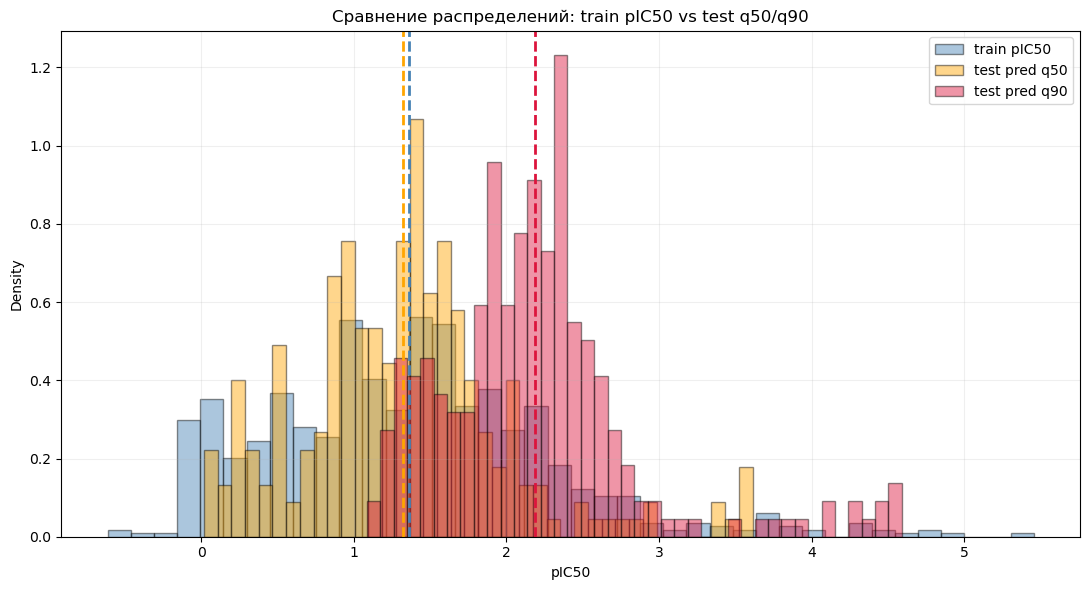

In [15]:
# логарифмический таргет train
train_pic50 = train["pIC50"].dropna()

# логарифмические предсказания квантилей на test
pred_q50 = pred_test_quantiles_pIC50[0.50]
pred_q90 = pred_test_quantiles_pIC50[0.90]

plt.figure(figsize=(11, 6))

# train
plt.hist(train_pic50, bins=40, alpha=0.45, label="train pIC50",
    color="steelblue", edgecolor="black", density=True)

# q50
plt.hist(pred_q50, bins=40, alpha=0.45, label="test pred q50", 
    color="orange", edgecolor="black", density=True)

# q90
plt.hist(pred_q90, bins=40, alpha=0.45, label="test pred q90",
    color="crimson", edgecolor="black", density=True)

# вертикальные линии средних
plt.axvline(train_pic50.mean(), color="steelblue", linestyle="--", linewidth=2)
plt.axvline(pred_q50.mean(), color="orange", linestyle="--", linewidth=2)
plt.axvline(pred_q90.mean(), color="crimson", linestyle="--", linewidth=2)

plt.title("Сравнение распределений: train pIC50 vs test q50/q90")
plt.xlabel("pIC50")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

По графику видно, что распределение предсказаний `q50` для `pIC50` достаточно близко к обучающему распределению и хорошо отражает его центральную часть. В то же время распределение `q90` заметно смещено вправо относительно train, что указывает на более высокие прогнозируемые значения и акцент на верхнем хвосте распределения.

Таким образом, `q50` можно рассматривать как наиболее сбалансированный вариант прогноза, тогда как `q90` формирует более оптимистичный сценарий и потенциально переоценивает высокие значения `pIC50`. Это соответствует ожидаемой логике квантильной регрессии, где верхние квантили описывают верхнюю границу возможных значений целевой переменной.